# Demand Forecasting for FMCG Products on Wildberries

## Business Problem

Accurate demand forecasting helps:

- reduce stockouts
- reduce overstocking
- improve inventory planning
- improve promotion planning

Goal:
Forecast daily product sales using historical sales data and product-level features.

## Forecasting Horizon

The forecasting horizon is set to 7 days ahead.

This setting reflects a realistic inventory planning scenario where replenishment and logistics decisions must be made in advance. Therefore, the model predicts demand one week ahead using only information available at the forecasting date.

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import random

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

DATE_START = '2021-01-01'
DATE_END   = '2025-01-01'
DATE_RANGE = pd.date_range(start=DATE_START, end=DATE_END, freq='D')

PRODUCT_KEY     = 'id_number'   # each row = unique SKU
SEQUENCE_LENGTH = 30
N_PER_BRAND     = 10            # top SKUs to keep per brand (controls RAM)
DEVICE          = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Load the data

In [5]:
FILE_PATH = '/content/drive/MyDrive/total_poroshok.csv'

df = (
    pd.read_csv(FILE_PATH)
      .drop(columns=['Unnamed: 0', 'id'], errors='ignore')
      .reset_index(drop=True)
)
# Row index acts as product key (itemid is NOT unique per product in this file)
df.insert(0, 'id_number', range(1, len(df) + 1))
df['name']  = df['name'].astype(str)
df['brand'] = df['brand'].astype(str)

print(f'Shape: {df.shape}')
print(f'Unique id_number: {df[PRODUCT_KEY].nunique()}')
df.head()

Shape: (28293, 99)
Unique id_number: 28293


/tmp/ipykernel_17467/4204757638.py:4: DtypeWarning: Columns (43) have mixed types. Specify dtype option on import or set low_memory=False.
  pd.read_csv(FILE_PATH)


,id_number,itemid,name,brand,seller,supplier_id,color,balance,balance_fbs,comments,rating,final_price,final_price_max,final_price_min,final_price_average,final_price_median,basic_sale,basic_price,promo_sale,client_sale,client_price,start_price,wallet_price,sales,sales_per_day_average,sales_per_comments,revenue,percent_from_revenue,revenue_potential,revenue_average,lost_profit,lost_profit_percent,days_in_site,days_in_stock,days_with_sales,average_if_in_stock,is_fbs,subject_id,subject,purchase,purchase_after_return,country,gender,sku_first_date,firstcommentdate,picscount,has3d,hasvideo,commentsvaluation,cardratingval,categories_last_count,category,category_position,graph,stocks_graph,price_graph,thumb,thumb_middle,url,turnover_days,turnover_once,frozen_stocks,frozen_stocks_cost,frozen_stocks_percent,search_words_count,search_position_avg,search_visibility,search_words_in_ad,category_position_avg,category_visibility,category_promo_count,warehouses_count,size_count,size_count_in_stock,avg_latest_rating,latest_negative_comments_percent,commission_fbo,commission_fbs,revenue_top_products_in_subject_percent,ext_advertising,related_products_count,related_products_in_stock_count,search_cpm_avg,search_ad_position_avg,search_organic_position_avg,top_hours,top_sells,description_length,name_length,package_length,package_width,package_height,last_parse_full_page,product_visibility_graph,category_graph,category_position_graph,search_position_graph,warehouses_count_graph,size_count_in_stock_graph
0,1,2363824,Порошок стиральный Автомат Color 80 стирок 12 кг,Tide,ООО Вайлдберриз,10743,NaN,10055,0,186308,5,1480,2199,0,1535.81,1549.5,32,1480,0,0,1480,2199,1450,270976,185.346101,1.45,416167480,0,525420428,284656.279070,109252948,20.793434,1590,1158,1172,234.003454,1,1078,Бытовая химия / Стиральные порошки,95,94,Россия,NaN,2020-08-25,2020-12-18,10,0,0,4.8,73,2,Дом/Хозяйственные товары/Стирка/Стиральный пор...,19,"[0, 4, 1, 4, 2, 5, 0, 2, 3, 2, 5, 3, 3, 3, 20,...","[142, 138, 137, 133, 131, 126, 126, 124, 121, ...","[1201, 1201, 1201, 1201, 1201, 1201, 1201, 120...",//basket-01.wbbasket.ru/vol142/part14239/14239...,//basket-01.wbbasket.ru/vol142/part14239/14239...,https://www.wildberries.ru/catalog/14239710/de...,42.97,53.148181,0,0,0.00,1216,38,1105,1212,900,1,0,1,0,0,4.07,26.67,19.5,19.5,0.0,1,21,10,991,39,13,[14],21,859,48,25,10,62,2024-12-26,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,2,2545215,Порошок стиральный Автомат Color 60 стирок 9 кг,Ariel,ООО Вайлдберриз,10743,NaN,6847,0,117687,5,1378,2135,890,1167.92,1353.0,30,1378,0,0,1378,1989,1350,211858,144.909713,1.80,247434058,0,283280025,169243.541724,35845967,12.653899,1646,1277,1283,165.902897,1,1078,Бытовая химия / Стиральные порошки,95,94,Россия,NaN,2020-06-30,2020-07-31,11,0,0,4.8,73,3,Дом/Хозяйственные товары/Стирка/Стиральный пор...,165,"[2, 1, 2, 3, 0, 0, 5, 7, 5, 4, 5, 4, 3, 5, 10,...","[519, 518, 516, 513, 513, 513, 508, 501, 497, ...","[1163, 1163, 1163, 1163, 1163, 1163, 1163, 116...",//basket-01.wbbasket.ru/vol130/part13027/13027...,//basket-01.wbbasket.ru/vol130/part13027/13027...,https://www.wildberries.ru/catalog/13027283/de...,41.27,57.523215,0,0,0.00,748,20,729,732,1348,1,1,1,0,0,4.13,26.67,19.5,19.5,0.0,1,12,8,1500,18,167,[13],5,1030,47,8,27,54,2025-01-01,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,3,2545215,Порошок стиральный Автомат Color 80 стирок 12 кг,Ariel,ООО Вайлдберриз,10743,NaN,6682,0,117687,5,1491,2676,0,1688.44,1719.0,39,1491,0,0,1491,2

## Parse pack weight from product name

In [6]:
WEIGHT_PATTERN = re.compile(
    r'(\d+(?:[.,]\d+)?)\s*(килограмм(?:ов)?|кг)',
    flags=re.IGNORECASE,
)

def extract_pack_weight_kg(name: str):
    """Extract pack weight in kg from the product name string."""
    m = WEIGHT_PATTERN.search(name)
    if not m:
        return np.nan
    return float(m.group(1).replace(',', '.'))

df['pack_weight_kg'] = df['name'].apply(extract_pack_weight_kg)

n_parsed = df['pack_weight_kg'].notna().sum()
print(f'Weight parsed for {n_parsed} / {len(df)} rows ({n_parsed / len(df):.1%})')

Weight parsed for 16149 / 28293 rows (57.1%)


## Parse sales and price time series

In [7]:
def parse_int_list(s, zero_as_nan=False):
    """Convert '[0, 4, 1, ...]' string into a list of ints. Optionally map zeros to NaN."""
    if pd.isna(s):
        return []
    s = str(s).strip().strip('[]')
    if not s:
        return []
    out = []
    for tok in s.split(','):
        tok = tok.strip()
        if not tok:
            continue
        try:
            v = int(float(tok))
        except ValueError:
            continue
        out.append(np.nan if (zero_as_nan and v == 0) else v)
    return out

df['graph']       = df['graph'].apply(lambda s: parse_int_list(s, zero_as_nan=False))
df['price_graph'] = df['price_graph'].apply(lambda s: parse_int_list(s, zero_as_nan=True))

expected_len = len(DATE_RANGE)
df['graph_len']       = df['graph'].apply(len)
df['price_graph_len'] = df['price_graph'].apply(len)

print(f'Expected length: {expected_len}')
print(f'Rows with correct graph length: {(df["graph_len"] == expected_len).sum()} / {len(df)}')

Expected length: 1462
Rows with correct graph length: 28293 / 28293


## Brand standartization

In [8]:
# Canonical name -> regex (case-insensitive)
BRAND_PATTERNS = {
    'Ariel':        r'ariel',
    'Tide':         r'\btide\b',
    'Persil':       r'persil|персил',
    'Losk':         r'\blosk\b|лоск',
    'Synergetic':   r'synergetic',
    'Clovin':       r'clovin',
    'BioMio':       r'biomio',
    'Ushasty Nyan': r'ушастый\s*нянь',
    'Myth':         r'\bмиф\b|\bmyth\b',
    'BIMAX':        r'bimax|бимакс',
    'ABC':          r'^\s*abc\s*$',
    'Chaika':       r'чайка',
    'Lion':         r'^\s*lion\s*$',
    'Amway':        r'amway',
    'Aist':         r'\bаист\b',
    'Kalyon':       r'kalyon',
    'Attack':       r'\battack\b',
    'Sarma':        r'sarma|сарма',
    'Dosia':        r'dosia|досия',
    'Ecowash':      r'ecowash'
}
COMPILED = {name: re.compile(pat, flags=re.IGNORECASE) for name, pat in BRAND_PATTERNS.items()}

def standardize_brand(raw):
    if not isinstance(raw, str) or raw.strip().lower() == 'nan':
        return np.nan
    for canonical, pat in COMPILED.items():
        if pat.search(raw):
            return canonical
    return raw

df['brand_raw'] = df['brand']
df['brand']     = df['brand'].apply(standardize_brand)

TARGET_BRANDS = list(BRAND_PATTERNS.keys())
n_matched = df['brand'].isin(TARGET_BRANDS).sum()
print(f'Standardized to canonical brands: {n_matched} / {len(df)} ({n_matched/len(df):.1%})')
print(df['brand'].value_counts(dropna=False).head(25))

Standardized to canonical brands: 12592 / 28293 (44.5%)
brand
Ariel           2981
Tide            1772
Persil          1189
Ushasty Nyan     897
ABC              790
NaN              665
Myth             593
BIMAX            464
Chaika           460
Amway            445
Lion             429
Clovin           412
Kalyon           365
Aist             331
Sarma            301
Attack           284
Synergetic       260
Losk             239
Dosia            184
BioMio           170
Мара             164
GRASS            156
AVE              155
Сонца            142
БИОЛАН           129
Name: count, dtype: int64


##  Filter to target brands and pick top-N SKUs per brand

In [9]:
EXPECTED_LEN = len(DATE_RANGE)

# Keep only SKUs of target brands with full-length graph
df_prod = df[
    df['brand'].isin(TARGET_BRANDS) & (df['graph_len'] == EXPECTED_LEN)
].copy()
print(f'After brand/length filter: {len(df_prod)} SKUs')

# Compute total sales per SKU to pick the most active ones
df_prod['total_sales'] = df_prod['graph'].apply(lambda x: int(np.sum(x)) if len(x) else 0)

# Keep top-N SKUs inside each brand
df_prod = (
    df_prod.sort_values(['brand', 'total_sales'], ascending=[True, False])
           .groupby('brand', as_index=False, group_keys=False)
           .head(N_PER_BRAND)
           .reset_index(drop=True)
)
df_prod = df_prod.drop(columns='total_sales')

print(f'\nAfter top-{N_PER_BRAND}-per-brand filter: {len(df_prod)} SKUs')
print(f'Distribution by brand:')
print(df_prod['brand'].value_counts())
print(f'\nApprox rows in df_daily: {len(df_prod) * EXPECTED_LEN:,}')

After brand/length filter: 12592 SKUs

After top-10-per-brand filter: 200 SKUs
Distribution by brand:
brand
ABC             10
Aist            10
Amway           10
Ariel           10
Attack          10
BIMAX           10
BioMio          10
Chaika          10
Clovin          10
Dosia           10
Ecowash         10
Kalyon          10
Lion            10
Losk            10
Myth            10
Persil          10
Sarma           10
Synergetic      10
Tide            10
Ushasty Nyan    10
Name: count, dtype: int64

Approx rows in df_daily: 292,400


In [10]:
sales_long = (
    df_prod[[PRODUCT_KEY, 'brand', 'graph']]
      .explode('graph', ignore_index=True)
      .rename(columns={'graph': 'sales'})
)
sales_long['date']  = np.tile(DATE_RANGE, len(df_prod))
sales_long['sales'] = pd.to_numeric(sales_long['sales'], errors='coerce').fillna(0).astype(int)

print(f'sales_long: {sales_long.shape}')
sales_long.head()

sales_long: (292400, 4)


,id_number,brand,sales,date
0,462,ABC,0,2021-01-01
1,462,ABC,0,2021-01-02
2,462,ABC,0,2021-01-03
3,462,ABC,0,2021-01-04
4,462,ABC,0,2021-01-05


## Build long-format price table

In [11]:
mask_price = (
    df_prod['pack_weight_kg'].notna()
    & (df_prod['pack_weight_kg'] > 0)
    & (df_prod['price_graph_len'] == EXPECTED_LEN)
)
df_price_prod = df_prod.loc[mask_price, [PRODUCT_KEY, 'pack_weight_kg', 'price_graph']].copy()
print(f'SKUs with valid price series: {len(df_price_prod)}')

price_long = (
    df_price_prod[[PRODUCT_KEY, 'pack_weight_kg', 'price_graph']]
      .explode('price_graph', ignore_index=True)
      .rename(columns={'price_graph': 'price'})
)
price_long['date']  = np.tile(DATE_RANGE, len(df_price_prod))
price_long['price'] = pd.to_numeric(price_long['price'], errors='coerce')
price_long['price_per_kg'] = price_long['price'] / price_long['pack_weight_kg']

# Drop extreme outliers in price per kg
price_long = price_long[price_long['price_per_kg'].between(50, 2000)]
print(f'price_long: {price_long.shape}')

SKUs with valid price series: 167
price_long: (176608, 5)


## Build static features lookup

In [12]:
# Safe static features only — leakage columns excluded
STATIC_NUMERIC = [
    'pack_weight_kg',
    'package_length', 'package_width', 'package_height',
    'comments', 'rating', 'commentsvaluation', 'cardratingval',
    'latest_negative_comments_percent', 'avg_latest_rating',
    'picscount', 'has3d', 'hasvideo',
    'description_length', 'name_length',
    'search_words_count', 'search_position_avg', 'search_visibility',
    'search_words_in_ad', 'category_position_avg', 'category_visibility',
    'category_promo_count', 'categories_last_count',
    'warehouses_count', 'size_count', 'size_count_in_stock',
    'commission_fbo', 'commission_fbs', 'is_fbs',
    'ext_advertising', 'related_products_count', 'related_products_in_stock_count',
    'search_cpm_avg', 'search_ad_position_avg', 'search_organic_position_avg',
    'revenue_top_products_in_subject_percent',
]
present_static = [c for c in STATIC_NUMERIC if c in df_prod.columns]
print(f'Static numeric features found: {len(present_static)}')

# Cast SKU launch date for later "days_since_launch" feature
if 'sku_first_date' in df_prod.columns:
    df_prod['sku_first_date'] = pd.to_datetime(df_prod['sku_first_date'], errors='coerce')

cols_for_static = [PRODUCT_KEY] + present_static
if 'sku_first_date' in df_prod.columns:
    cols_for_static.append('sku_first_date')

static_df = df_prod[cols_for_static].copy()
print(f'static_df: {static_df.shape}')

Static numeric features found: 36
static_df: (200, 38)


## Merge into daily panel

In [13]:
df_daily = (
    sales_long
        .merge(price_long[[PRODUCT_KEY, 'date', 'price_per_kg']],
               on=[PRODUCT_KEY, 'date'], how='left')
        .merge(static_df, on=PRODUCT_KEY, how='left', validate='m:1')
        .sort_values([PRODUCT_KEY, 'date'])
        .reset_index(drop=True)
)

# Product age in days at each timestamp
if 'sku_first_date' in df_daily.columns:
    df_daily['days_since_launch'] = (
        (df_daily['date'] - df_daily['sku_first_date']).dt.days.clip(lower=0)
    )
    df_daily['days_since_launch'] = df_daily['days_since_launch'].fillna(
        df_daily['days_since_launch'].median()
    )
    df_daily = df_daily.drop(columns='sku_first_date')

print(f'df_daily shape: {df_daily.shape}')
print(f'Unique products: {df_daily[PRODUCT_KEY].nunique()}')
df_daily.head()

df_daily shape: (292400, 42)
Unique products: 200


,id_number,brand,sales,date,price_per_kg,pack_weight_kg,package_length,package_width,package_height,comments,rating,commentsvaluation,cardratingval,latest_negative_comments_percent,avg_latest_rating,picscount,has3d,hasvideo,description_length,name_length,search_words_count,search_position_avg,search_visibility,search_words_in_ad,category_position_avg,category_visibility,category_promo_count,categories_last_count,warehouses_count,size_count,size_count_in_stock,commission_fbo,commission_fbs,is_fbs,ext_advertising,related_products_count,related_products_in_stock_count,search_cpm_avg,search_ad_position_avg,search_organic_position_avg,revenue_top_products_in_subject_percent,days_since_launch
0,1,Tide,0,2021-01-01,100.083333,12.0,25,10,62,186308,5,4.8,73,26.67,4.07,10,0,0,859,48,1216,38,1105,1212,900,1,0,2,1,0,0,19.5,19.5,1,1,21,10,991,39,13,0.0,129
1,1,Tide,4,2021-01-02,100.083333,12.0,25,10,62,186308,5,4.8,73,26.67,4.07,10,0,0,859,48,1216,38,1105,1212,900,1,0,2,1,0,0,19.5,19.5,1,1,21,10,991,39,13,0.0,130
2,1,Tide,1,2021-01-03,100.083333,12.0,25,10,62,186308,5,4.8,73,26.67,4.07,10,0,0,859,48,1216,38,1105,1212,900,1,0,2,1,0,0,19.5,19.5,1,1,21,10,991,39,13,0.0,131
3,1,Tide,4,2021-01-04,100.083333,12.0,25,10,62,186308,5,4.8,73,26.67,4.07,10,0,0,859,48,1216,38,1105,1212,900,1,0,2,1,0,0,19.5,19.5,1,1,21,10,991,39,13,0.0,132
4,1,Tide,2,2021-01-05,100.083333,12.0,25,10,62,186308,5,4.8,73,26.67,4.07,10,0,0,859,48,1216,38,1105,1212,900,1,0,2,1,0,0,19.5,19.5,1,1,21,10,991,39,13,0.0,133


## Month aggregation
Monthly aggregation was explored as an alternative forecasting granularity but was not used in the final model because daily forecasting preserved more information and produced more meaningful predictions.

In [14]:
# Monthly aggregation with keeping all other columns

agg_dict = {
    'sales': 'sum',
    'price_per_kg': 'mean'
}

# For all remaining columns -> take first value within month
for col in df_daily.columns:
    if col not in ['id_number', 'date', 'sales', 'price_per_kg']:
        agg_dict[col] = 'first'

df_monthly = (
    df_daily
        .assign(month=lambda x: x['date'].dt.to_period('M').dt.to_timestamp())
        .groupby(['id_number', 'month'], as_index=False)
        .agg(agg_dict)
        .sort_values(['id_number', 'month'])
        .reset_index(drop=True)
)

print(f'df_monthly shape: {df_monthly.shape}')
df_monthly.head()

df_monthly shape: (9800, 42)


,id_number,month,sales,price_per_kg,brand,pack_weight_kg,package_length,package_width,package_height,comments,rating,commentsvaluation,cardratingval,latest_negative_comments_percent,avg_latest_rating,picscount,has3d,hasvideo,description_length,name_length,search_words_count,search_position_avg,search_visibility,search_words_in_ad,category_position_avg,category_visibility,category_promo_count,categories_last_count,warehouses_count,size_count,size_count_in_stock,commission_fbo,commission_fbs,is_fbs,ext_advertising,related_products_count,related_products_in_stock_count,search_cpm_avg,search_ad_position_avg,search_organic_position_avg,revenue_top_products_in_subject_percent,days_since_launch
0,1,2021-01-01,200,96.564516,Tide,12.0,25,10,62,186308,5,4.8,73,26.67,4.07,10,0,0,859,48,1216,38,1105,1212,900,1,0,2,1,0,0,19.5,19.5,1,1,21,10,991,39,13,0.0,129
1,1,2021-02-01,128,93.619048,Tide,12.0,25,10,62,186308,5,4.8,73,26.67,4.07,10,0,0,859,48,1216,38,1105,1212,900,1,0,2,1,0,0,19.5,19.5,1,1,21,10,991,39,13,0.0,160
2,1,2021-03-01,105,104.510753,Tide,12.0,25,10,62,186308,5,4.8,73,26.67,4.07,10,0,0,859,48,1216,38,1105,1212,900,1,0,2,1,0,0,19.5,19.5,1,1,21,10,991,39,13,0.0,188
3,1,2021-04-01,237,96.283333,Tide,12.0,25,10,62,186308,5,4.8,73,26.67,4.07,10,0,0,859,48,1216,38,1105,1212,900,1,0,2,1,0,0,19.5,19.5,1,1,21,10,991,39,13,0.0,219
4,1,2021-05-01,844,88.620968,Tide,12.0,25,10,62,186308,5,4.8,73,26.67,4.07,10,0,0,859,48,1216,38,1105,1212,900,1,0,2,1,0,0,19.5,19.5,1,1,21,10,991,39,13,0.0,249


## EDA

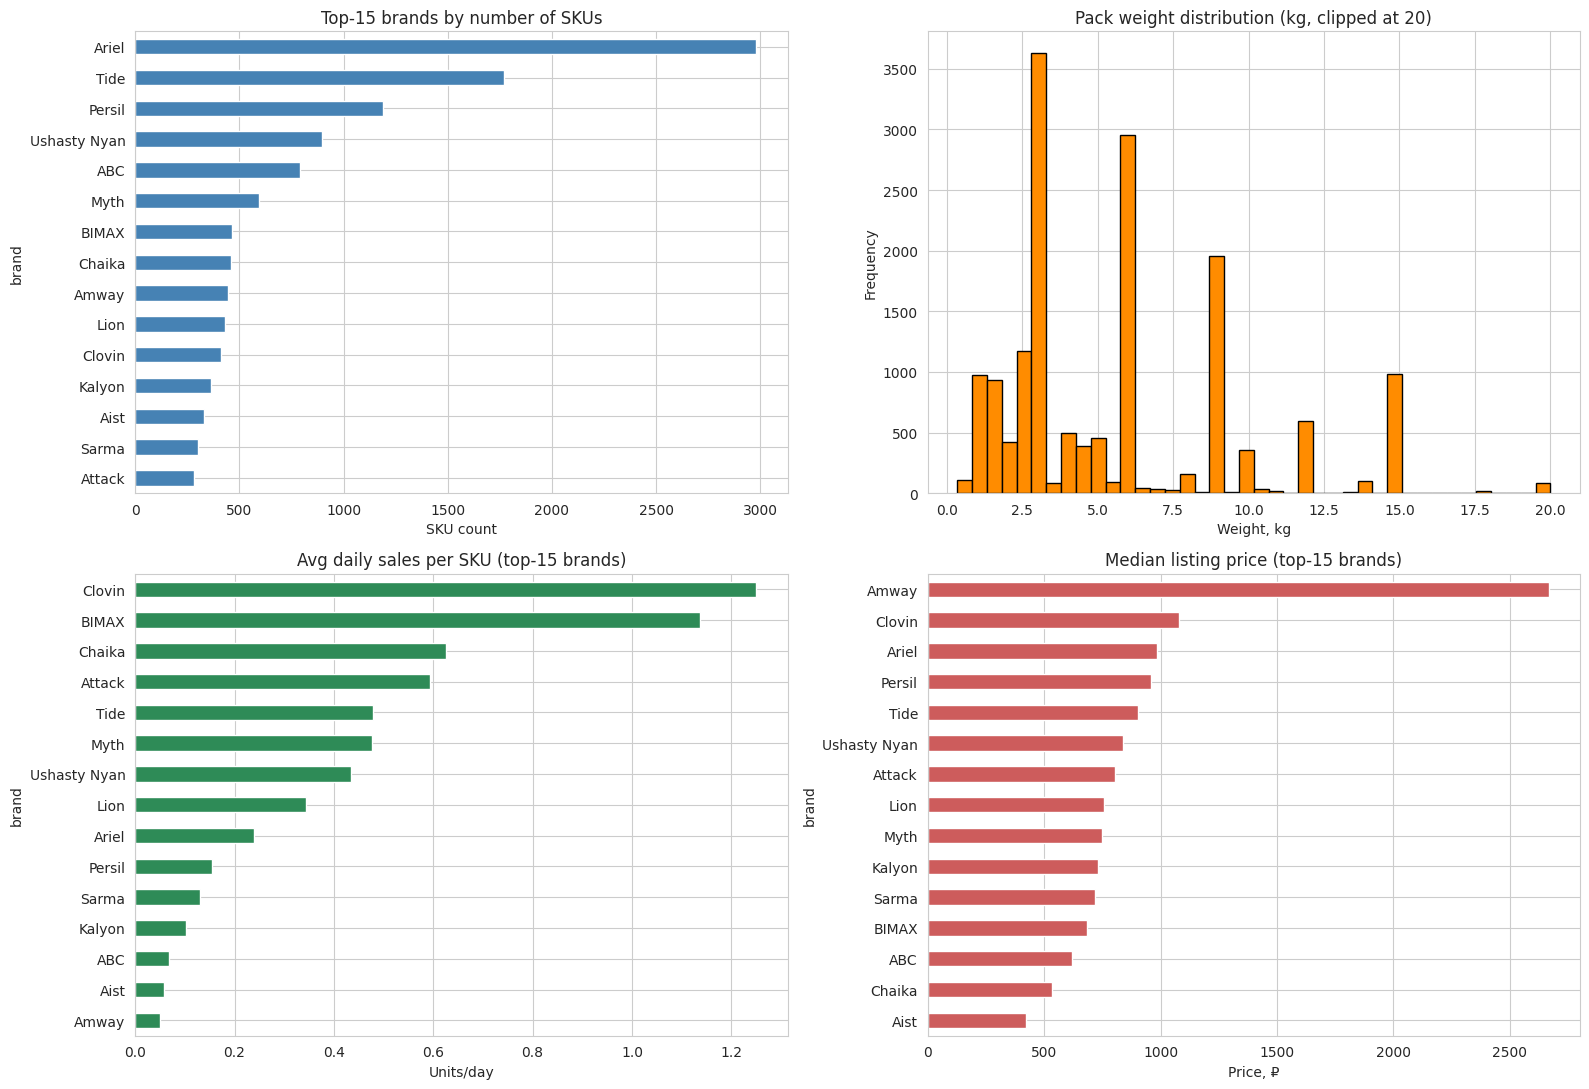

In [15]:
TOP_BRANDS = df['brand'].value_counts().head(15).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# 1. Топ-15 брендов по числу SKU
df['brand'].value_counts().head(15).iloc[::-1].plot(
    kind='barh', ax=axes[0, 0], color='steelblue'
)
axes[0, 0].set_title('Top-15 brands by number of SKUs')
axes[0, 0].set_xlabel('SKU count')

# 2. Распределение веса упаковки
df['pack_weight_kg'].dropna().clip(upper=20).plot(
    kind='hist', bins=40, ax=axes[0, 1], color='darkorange', edgecolor='black'
)
axes[0, 1].set_title('Pack weight distribution (kg, clipped at 20)')
axes[0, 1].set_xlabel('Weight, kg')

# 3. Средние дневные продажи по топ-брендам
mean_daily_sales = (
    df[df['brand'].isin(TOP_BRANDS)]
      .assign(mean_sales=lambda d: d['graph'].apply(lambda x: np.mean(x) if len(x) else np.nan))
      .groupby('brand')['mean_sales'].mean()
      .sort_values()
)
mean_daily_sales.plot(kind='barh', ax=axes[1, 0], color='seagreen')
axes[1, 0].set_title('Avg daily sales per SKU (top-15 brands)')
axes[1, 0].set_xlabel('Units/day')

# 4. Средняя цена по топ-брендам (медиана по ненулевым ценам)
mean_price = (
    df[df['brand'].isin(TOP_BRANDS)]
      .assign(med_price=lambda d: d['price_graph'].apply(
          lambda x: np.nanmedian(x) if len(x) and np.any(~np.isnan(x)) else np.nan))
      .groupby('brand')['med_price'].median()
      .sort_values()
)
mean_price.plot(kind='barh', ax=axes[1, 1], color='indianred')
axes[1, 1].set_title('Median listing price (top-15 brands)')
axes[1, 1].set_xlabel('Price, ₽')

plt.tight_layout()
plt.show()

In [16]:

import plotly.express as px

# Aggregate sales by brand and month
brand_sales = (
    df_monthly
        .groupby(['brand', 'month'], as_index=False)['sales']
        .sum()
)

# Interactive plot
fig = px.line(
    brand_sales,
    x='month',
    y='sales',
    color='brand',
    title='Monthly Sales Dynamics by Brand',
    labels={
        'month': 'Month',
        'sales': 'Total Sales'
    }
)

fig.show()

In [17]:

# Average monthly price per kg by brand
brand_price = (
    df_monthly
        .groupby(['brand', 'month'], as_index=False)['price_per_kg']
        .mean()
)

# Interactive plot
fig = px.line(
    brand_price,
    x='month',
    y='price_per_kg',
    color='brand',
    title='Average Monthly Price per KG by Brand',
    labels={
        'month': 'Month',
        'price_per_kg': 'Average Price per KG'
    }
)

fig.show()

# Sales Forecasting

In [18]:
import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [19]:
# ============================================================
# Feature engineering
# ============================================================

PRODUCT_KEY = 'id_number'

# -----------------------------
# Lags
# -----------------------------

for lag in [1, 7, 14, 30]:

    df_daily[f'sales_lag_{lag}'] = (
        df_daily
            .groupby(PRODUCT_KEY)['sales']
            .shift(lag)
    )

# -----------------------------
# Rolling statistics
# -----------------------------

for window in [7, 14, 30]:

    df_daily[f'rolling_mean_{window}'] = (
        df_daily
            .groupby(PRODUCT_KEY)['sales']
            .transform(lambda x: x.shift(1).rolling(window).mean())
    )

    df_daily[f'rolling_std_{window}'] = (
        df_daily
            .groupby(PRODUCT_KEY)['sales']
            .transform(lambda x: x.shift(1).rolling(window).std())
    )

# -----------------------------
# Calendar features
# -----------------------------

df_daily['dayofweek'] = df_daily['date'].dt.dayofweek
df_daily['month'] = df_daily['date'].dt.month

# cyclic encoding

df_daily['dow_sin'] = np.sin(2 * np.pi * df_daily['dayofweek'] / 7)
df_daily['dow_cos'] = np.cos(2 * np.pi * df_daily['dayofweek'] / 7)

df_daily['month_sin'] = np.sin(2 * np.pi * df_daily['month'] / 12)
df_daily['month_cos'] = np.cos(2 * np.pi * df_daily['month'] / 12)

print(df_daily.shape)

(292400, 58)


In [20]:
# ============================================================
# Missing values
# ============================================================

numeric_cols = df_daily.select_dtypes(include=[np.number]).columns

for col in numeric_cols:
    df_daily[col] = df_daily[col].fillna(df_daily[col].median())

print(df_daily.isna().sum().sum())

0


In [21]:
# ============================================================
# Extreme values
# ============================================================

bad_products = df_daily.loc[
    df_daily['sales'] > 5000,
    'id_number'
].unique()

df_daily = df_daily[
    ~df_daily['id_number'].isin(bad_products)
].copy()

In [22]:
# ============================================================
# Log transforms
# ============================================================

heavy_tail_cols = [
    # 'sales',
    'comments'
]

for col in heavy_tail_cols:
    df_daily[col] = np.log1p(df_daily[col])

In [23]:
# ============================================================
# Remove rows after lag generation
# ============================================================

df_daily = df_daily.dropna().reset_index(drop=True)

print(df_daily.shape)

(290938, 58)


In [24]:
df_daily['sales_target_7d'] = (
    df_daily
    .groupby(PRODUCT_KEY)['sales']
    .shift(-7)
)

In [25]:
df_daily = df_daily.dropna(
    subset=['sales_target_7d']
).copy()

In [26]:
train_end = '2023-06-30'
val_end = '2024-03-31'

In [27]:
# ============================================================
# Train / Validation / Test split
# ============================================================

train_df = (
    df_daily[df_daily['date'] <= train_end]
    .copy()
)

val_df = (
    df_daily[
        (df_daily['date'] > train_end) &
        (df_daily['date'] <= val_end)
    ]
    .copy()
)

test_df = (
    df_daily[df_daily['date'] > val_end]
    .copy()
)

print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

(181289, 59)
(54725, 59)
(53531, 59)


In [28]:
print("Products:", train_df[PRODUCT_KEY].nunique())

print(train_df['brand'].value_counts())

Products: 199
brand
Tide            9110
Ecowash         9110
Synergetic      9110
Myth            9110
Losk            9110
BioMio          9110
Persil          9110
Ushasty Nyan    9110
Chaika          9110
BIMAX           9110
Clovin          9110
Lion            9110
Amway           9110
Attack          9110
Sarma           9110
Kalyon          9110
ABC             9110
Aist            9110
Dosia           9110
Ariel           8199
Name: count, dtype: int64


## Baseline Models

To evaluate whether the proposed neural network provides additional value, two simple benchmark models are used.

- Lag 7: predicts demand seven days ahead using demand observed one week earlier.
- Rolling Mean 7: predicts future demand using the average demand over the previous seven days.

These baselines represent common heuristic approaches frequently used in demand forecasting.

In [29]:
baseline_df = df_daily.copy()

In [30]:
baseline_test = baseline_df[
    baseline_df['date'] > val_end
]

### Baseline 1: Previous Week

In [31]:
mae_lag7_real = mean_absolute_error(
    baseline_test['sales_target_7d'],
    baseline_test['sales_lag_7']
)

rmse_lag7_real = np.sqrt(
    mean_squared_error(
        baseline_test['sales_target_7d'],
        baseline_test['sales_lag_7']
    )
)

print(f"MAE: {mae_lag7_real:.4f}")
print(f"RMSE: {rmse_lag7_real:.4f}")

MAE: 15.4515
RMSE: 56.6950


### Baseline 2: Rolling Mean 7

In [32]:
mae_roll_real = mean_absolute_error(
    baseline_test['sales_target_7d'],
    baseline_test['rolling_mean_7']
)

rmse_roll_real = np.sqrt(
    mean_squared_error(
        baseline_test['sales_target_7d'],
        baseline_test['rolling_mean_7']
    )
)

print(f"MAE: {mae_roll_real:.4f}")
print(f"RMSE: {rmse_roll_real:.4f}")

MAE: 13.0653
RMSE: 48.5134


### Feature Selection

The feature set combines:

- historical demand information (lags and rolling statistics);
- price information;
- product popularity indicators.

The selected features allow the model to capture:
- short-term demand dynamics;
- weekly demand patterns;
- pricing effects;
- differences between products.

In [33]:
FEATURES = [

    # price
    'price_per_kg',

    # lags
    'sales_lag_1',
    'sales_lag_7',
    'sales_lag_14',
    'sales_lag_30',

    # rolling
    'rolling_mean_7',
    'rolling_std_7',
    'rolling_mean_14',
    'rolling_mean_30',
    'rolling_std_14',
    'rolling_std_30',

    # calendar
    'dow_sin',
    'dow_cos',

    'month_sin',
    'month_cos',

    # popularity
    'comments',
    'rating'

]

TARGET = 'sales_target_7d'

## CNN + Transformer Hybrid

The proposed architecture combines convolutional and attention-based neural network components.

The CNN block captures local temporal patterns such as short-term demand fluctuations and sudden changes in sales.

The Transformer block models longer-term dependencies using self-attention and helps identify relationships across a larger temporal context.

The hybrid approach was selected because demand forecasting requires both local trend extraction and long-range temporal modeling.

In [34]:
# ============================================================
# Scaling
# ============================================================

scaler = StandardScaler()

train_df[FEATURES] = scaler.fit_transform(train_df[FEATURES])

val_df[FEATURES] = scaler.transform(val_df[FEATURES])

test_df[FEATURES] = scaler.transform(test_df[FEATURES])

In [35]:
# ============================================================
# FAST Dataset
# ============================================================


class SalesDataset(Dataset):

    def __init__(self, df, features, target, seq_len=30):

        self.X = []
        self.y = []

        grouped = df.groupby(PRODUCT_KEY)

        for _, product_df in grouped:

            product_df = product_df.sort_values('date')

            if len(product_df) <= seq_len:
                continue

            feature_array = product_df[
                features
            ].values.astype(np.float32)

            target_array = product_df[
                target
            ].values.astype(np.float32)

            for i in range(seq_len, len(product_df)):

                self.X.append(
                    feature_array[i-seq_len:i]
                )

                self.y.append(
                    target_array[i]
                )

        self.X = torch.tensor(
            np.array(self.X),
            dtype=torch.float32
        )

        self.y = torch.tensor(
            np.array(self.y),
            dtype=torch.float32
        )

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

A sequence length of 30 days was selected.

This window captures recent demand dynamics while reducing model complexity and training time.

For FMCG products on marketplaces, recent sales patterns are often more informative than older observations.

In [36]:
# ============================================================
# Dataloaders
# ============================================================

train_dataset = SalesDataset(
    train_df,
    FEATURES,
    TARGET,
    SEQUENCE_LENGTH
)

val_dataset = SalesDataset(
    val_df,
    FEATURES,
    TARGET,
    SEQUENCE_LENGTH
)

test_dataset = SalesDataset(
    test_df,
    FEATURES,
    TARGET,
    SEQUENCE_LENGTH
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

print(len(train_dataset))
print(len(val_dataset))
print(len(test_dataset))

175319
48755
47561


In [37]:
# ============================================================
# Positional Encoding
# ============================================================

class PositionalEncoding(nn.Module):

    def __init__(self, d_model, max_len=5000):

        super().__init__()

        pe = torch.zeros(max_len, d_model)

        position = torch.arange(
            0,
            max_len
        ).unsqueeze(1)

        div_term = torch.exp(
            torch.arange(0, d_model, 2)
            * (-np.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)

        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)

        self.register_buffer('pe', pe)

    def forward(self, x):

        return x + self.pe[:, :x.size(1)]

In [38]:
# ============================================================
# CNN + Transformer
# ============================================================

class CNNTransformer(nn.Module):

    def __init__(
        self,
        num_features,
        hidden_dim=32,
        num_heads=2,
        num_layers=1,
        dropout=0.1
    ):

        super().__init__()

        self.cnn = nn.Sequential(

            nn.Conv1d(
                num_features,
                hidden_dim,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU()
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim,
            nhead=num_heads,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):

        x = x.permute(0, 2, 1)

        x = self.cnn(x)

        x = x.permute(0, 2, 1)

        x = self.transformer(x)

        x = x[:, -1, :]

        out = self.fc(x)

        return out.squeeze()

In [39]:
# ============================================================
# Model
# ============================================================

model = CNNTransformer(
    num_features=len(FEATURES),
    hidden_dim=32,
    num_heads=2,
    num_layers=1,
    dropout=0.1
).to(DEVICE)

criterion = nn.SmoothL1Loss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2
)

print(model)

CNNTransformer(
  (cnn): Sequential(
    (0): Conv1d(17, 32, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): ReLU()
  )
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0): TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
        )
        (linear1): Linear(in_features=32, out_features=2048, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=2048, out_features=32, bias=True)
        (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (fc): Linear(in_features=32, out_features=1, bias=True)
)


In [40]:
# ============================================================
# Training functions
# ============================================================

def train_epoch(model, loader):

    model.train()

    losses = []

    for X_batch, y_batch in loader:

        X_batch = X_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)

        optimizer.zero_grad()

        preds = model(X_batch)

        loss = criterion(preds, y_batch)

        loss.backward()

        optimizer.step()

        losses.append(loss.item())

    return np.mean(losses)


@torch.no_grad()
def evaluate(model, loader):

    model.eval()

    losses = []

    all_preds = []
    all_targets = []

    for X_batch, y_batch in loader:

        X_batch = X_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)

        preds = model(X_batch)

        loss = criterion(preds, y_batch)

        losses.append(loss.item())

        all_preds.extend(
            preds.cpu().numpy()
        )

        all_targets.extend(
            y_batch.cpu().numpy()
        )

    mae = mean_absolute_error(
        all_targets,
        all_preds
    )

    rmse = np.sqrt(
        mean_squared_error(
            all_targets,
            all_preds
        )
    )

    return (
        np.mean(losses),
        mae,
        rmse
    )

@torch.no_grad()
def get_predictions(model, loader):

    model.eval()

    all_preds = []
    all_targets = []

    for X_batch, y_batch in loader:

        X_batch = X_batch.to(DEVICE)

        preds = model(X_batch)

        all_preds.extend(
            preds.cpu().numpy()
        )

        all_targets.extend(
            y_batch.numpy()
        )

    return (
        np.array(all_targets),
        np.array(all_preds)
    )

In [41]:
# ============================================================
# Training loop
# ============================================================

EPOCHS = 15

train_losses = []
val_losses = []

best_rmse = np.inf

patience = 4
counter = 0

for epoch in range(EPOCHS):

    train_loss = train_epoch(
        model,
        train_loader
    )

    val_loss, val_mae, val_rmse = evaluate(
        model,
        val_loader
    )

    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(
        f'Epoch {epoch+1}/{EPOCHS} | '
        f'Train Loss: {train_loss:.4f} | '
        f'Val Loss: {val_loss:.4f} | '
        f'Val MAE: {val_mae:.4f} | '
        f'Val RMSE: {val_rmse:.4f}'
    )

    if val_rmse < best_rmse:

        best_rmse = val_rmse

        counter = 0

        torch.save(
            model.state_dict(),
            'best_model.pth'
        )

    else:

        counter += 1

        if counter >= patience:

            print('Early stopping')

            break

Epoch 1/15 | Train Loss: 9.7599 | Val Loss: 23.5321 | Val MAE: 24.0098 | Val RMSE: 97.2997
Epoch 2/15 | Train Loss: 8.8462 | Val Loss: 23.0344 | Val MAE: 23.4627 | Val RMSE: 94.5129
Epoch 3/15 | Train Loss: 8.6351 | Val Loss: 22.6929 | Val MAE: 23.1619 | Val RMSE: 94.6211
Epoch 4/15 | Train Loss: 8.5205 | Val Loss: 22.7256 | Val MAE: 23.1032 | Val RMSE: 94.1610
Epoch 5/15 | Train Loss: 8.4189 | Val Loss: 22.5895 | Val MAE: 23.0414 | Val RMSE: 94.9668
Epoch 6/15 | Train Loss: 8.3357 | Val Loss: 22.8470 | Val MAE: 23.2633 | Val RMSE: 92.8400
Epoch 7/15 | Train Loss: 8.2852 | Val Loss: 22.6790 | Val MAE: 23.1551 | Val RMSE: 93.1933
Epoch 8/15 | Train Loss: 8.2270 | Val Loss: 22.8218 | Val MAE: 23.1969 | Val RMSE: 93.2672
Epoch 9/15 | Train Loss: 8.0523 | Val Loss: 22.7500 | Val MAE: 23.1631 | Val RMSE: 92.0479
Epoch 10/15 | Train Loss: 7.9688 | Val Loss: 22.7286 | Val MAE: 23.1122 | Val RMSE: 93.4031
Epoch 11/15 | Train Loss: 7.9141 | Val Loss: 22.6203 | Val MAE: 23.0026 | Val RMSE: 92.86

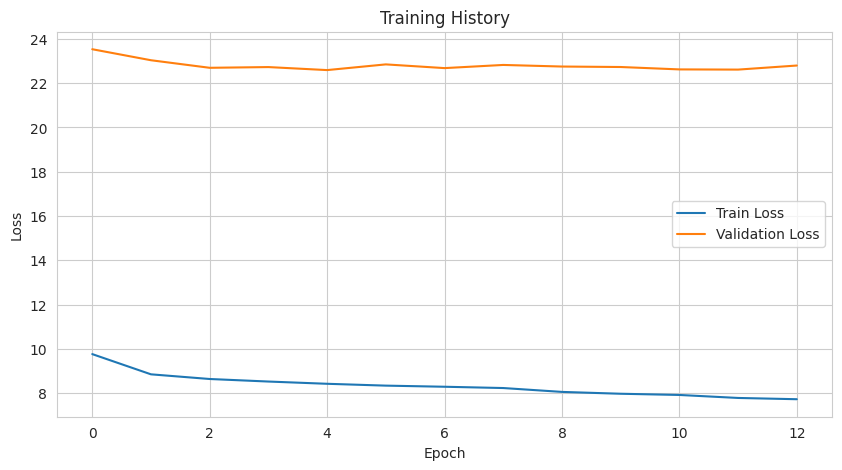

In [42]:
# ============================================================
# Training history
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    train_losses,
    label='Train Loss'
)

plt.plot(
    val_losses,
    label='Validation Loss'
)

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.title('Training History')

plt.legend()

plt.show()

In [43]:
# ============================================================
# Final evaluation
# ============================================================

model.load_state_dict(
    torch.load('best_model.pth')
)

test_loss, mae_cnn_real, rmse_cnn_real = evaluate(
    model,
    test_loader
)

print(f'TEST MAE: {mae_cnn_real:.4f}')
print(f'TEST RMSE: {rmse_cnn_real:.4f}')

TEST MAE: 13.1712
TEST RMSE: 45.1500


In [44]:
# ============================================================
# Predictions
# ============================================================

@torch.no_grad()
def get_predictions(model, loader):

    model.eval()

    preds = []
    targets = []

    for X_batch, y_batch in loader:

        X_batch = X_batch.to(DEVICE)

        batch_preds = model(X_batch)

        preds.extend(
            batch_preds.cpu().numpy()
        )

        targets.extend(
            y_batch.numpy()
        )

    return (
        np.array(preds),
        np.array(targets)
    )


preds, targets = get_predictions(
    model,
    test_loader
)

## Forecast Visualization

The model successfully captures the overall sales dynamics and follows the main demand trends.

While some demand spikes are underestimated, the predicted series closely follows the actual trajectory, indicating that the model learned meaningful temporal patterns.

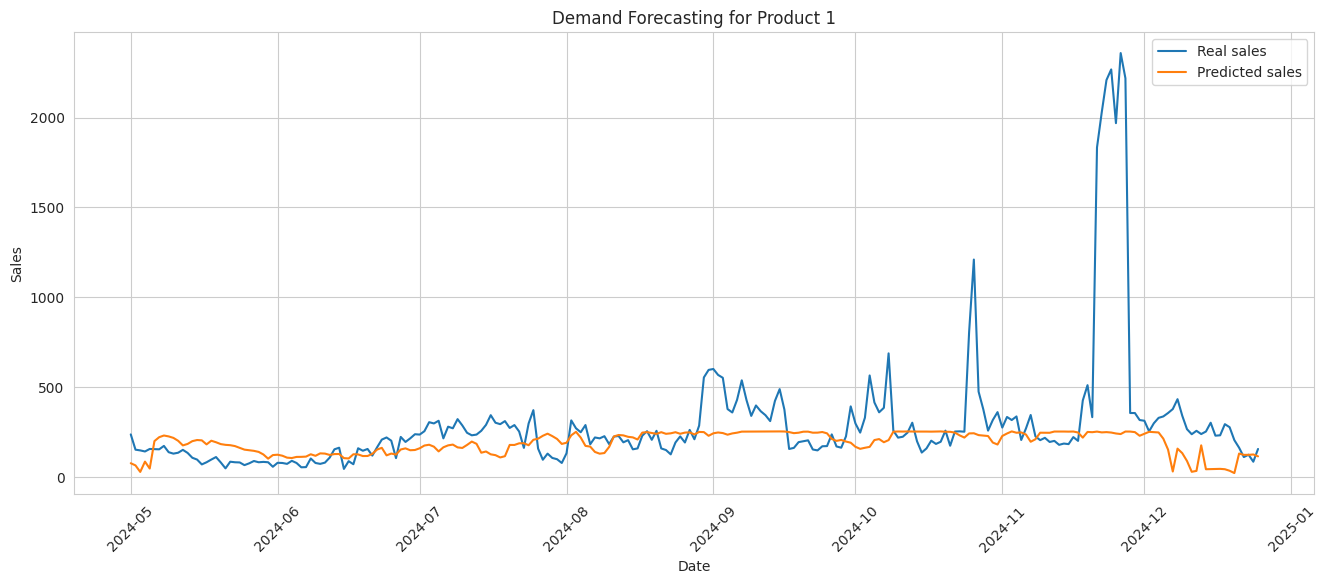

In [45]:
# ============================================================
# Forecast visualization for one product
# ============================================================

model.eval()

example_product = test_df[PRODUCT_KEY].unique()[0]

product_df = (
    test_df[test_df[PRODUCT_KEY] == example_product]
        .sort_values('date')
        .reset_index(drop=True)
)

preds = []
targets = []
dates = []

for i in range(SEQUENCE_LENGTH, len(product_df)):

    X = product_df[FEATURES].iloc[
        i-SEQUENCE_LENGTH:i
    ].values

    y = product_df[TARGET].iloc[i]

    X_tensor = torch.tensor(
        X,
        dtype=torch.float32
    ).unsqueeze(0).to(DEVICE)

    with torch.no_grad():

        pred = model(X_tensor).item()

    preds.append(pred)
    targets.append(y)
    dates.append(product_df['date'].iloc[i])

plt.figure(figsize=(16, 6))

plt.plot(
    dates,
    targets,
    label='Real sales'
)

plt.plot(
    dates,
    preds,
    label='Predicted sales'
)

plt.title(
    f'Demand Forecasting for Product {example_product}'
)

plt.xlabel('Date')
plt.ylabel('Sales')

plt.legend()

plt.xticks(rotation=45)

plt.show()

The model tends to underestimate extreme demand spikes. This behavior is expected because promotional events and marketing campaigns are not available among the explanatory variables.

In [46]:
results_real = pd.DataFrame({
    'Model': [
        'Baseline 1: Lag 7',
        'Baseline 2: Rolling Mean 7',
        'CNN-Transformer'
    ],
    'MAE (units)': [
        mae_lag7_real,
        mae_roll_real,
        mae_cnn_real
    ],
    'RMSE (units)': [
        rmse_lag7_real,
        rmse_roll_real,
        rmse_cnn_real
    ]
})

results_real.sort_values('RMSE (units)')

,Model,MAE (units),RMSE (units)
2,CNN-Transformer,13.171172,45.149976
1,Baseline 2: Rolling Mean 7,13.065327,48.513415
0,Baseline 1: Lag 7,15.451458,56.695030


### Evaluation Metric

Both MAE and RMSE are reported.

RMSE is considered the primary evaluation metric because it penalizes large forecasting errors more heavily.

In inventory planning, large forecasting mistakes are substantially more costly than small deviations, as they may lead to stockouts, overstocking, and increased logistics costs.

Therefore, RMSE better reflects the practical business impact of forecasting quality.

# Conclusion

A CNN-Transformer hybrid model was developed for 7-day-ahead demand forecasting using Wildberries FMCG sales data.

The forecasting problem was formulated from an inventory planning perspective, where future demand must be estimated one week in advance rather than predicted for the next day.

The final feature set included historical demand information, rolling statistics, pricing variables, and product characteristics.

Model performance was evaluated against two benchmark approaches:

- Lag 7
- Rolling Mean 7

The CNN-Transformer achieved the lowest RMSE among all evaluated approaches, outperforming both benchmark models.

The results indicate that combining convolutional feature extraction with Transformer-based temporal modeling allows the model to capture demand patterns that cannot be represented by simple heuristic forecasting rules.

The developed solution can be applied to support inventory planning, replenishment decisions, and logistics management in FMCG e-commerce environments.